[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR-USERNAME/mapping-indias-digital-fraud-surge/blob/main/notebooks/analysis.ipynb)

# Mapping India's Digital Fraud Surge
### State-wise analysis of cyber & financial fraud trends in India (2019–2024)

> ⚠️ **Synthetic data notice:** Real government data sources are cited below; due to access/format constraints, this version uses a **synthetic dataset modeled on real published NCRP/NCRB statistics and trends**, so the analysis approach is portfolio-ready and can be re-run on live data later. See `generate_data.py` for exactly how the synthetic numbers were grounded in real reported figures.

**What this notebook does:** loads state/UT-level cyber fraud data, cleans it (missing values, inconsistent state names, duplicates, a data-integrity check), and analyzes national trends, the worst-hit states, how fast fraud is growing by state, which fraud types are taking over, and how well cases actually get prosecuted.

**Data sources (for the real version of this project):**
- [data.gov.in — Open Government Data Platform](https://data.gov.in) (National Cyber Crime Reporting Portal stats)
- [NCRB "Crime in India" reports](https://ncrb.gov.in)
- [Dataful.in](https://dataful.in) — pre-cleaned NCRB cyber crime datasets

## 1. Load the data

In [1]:
# Running this notebook in Google Colab? This cell clones the project repo
# so the relative paths below ("../data/...") work the same way they do when
# running locally in Jupyter. If you're already running locally, it does nothing.
import os

IN_COLAB = "google.colab" in str(get_ipython())

if IN_COLAB:
    REPO_URL = "https://github.com/janvisri/mapping-indias-digital-fraud-surge.git"
    REPO_NAME = "mapping-indias-digital-fraud-surge"
    if not os.path.exists(REPO_NAME):
        !git clone {REPO_URL}
    os.chdir(f"{REPO_NAME}/notebooks")
    print("Running in Colab - cloned the repo and moved into notebooks/")
else:
    print("Running locally - no setup needed")


Running locally - no setup needed


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# a couple of small style tweaks so the charts don't look like defaults
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
COLOR = "#2a6f97"   # one main color, reused everywhere for consistency

df = pd.read_csv("../data/cyber_fraud_data.csv")
df.head()

,state_ut,year,fraud_type,cases_registered,cases_chargesheeted,cases_convicted,persons_arrested,amount_saved_inr,complaints_count
0,Karnataka,2021,Online Banking Fraud,91,55,5.0,97,4895184.34,108
1,Rajasthan,2022,UPI Fraud,232,91,7.0,168,1286174.47,343
2,Madhya Pradesh,2023,UPI Fraud,398,147,12.0,125,3474913.44,501
3,Chhattisgarh,2022,OTP Fraud,37,13,1.0,17,463908.80,59
4,Telangana,2024,Other,127,68,6.0,60,1412782.46,217


In [3]:
print(df.shape)
df.info()

(1081, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1081 entries, 0 to 1080
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   state_ut             1081 non-null   str    
 1   year                 1081 non-null   int64  
 2   fraud_type           1081 non-null   str    
 3   cases_registered     1081 non-null   int64  
 4   cases_chargesheeted  1081 non-null   int64  
 5   cases_convicted      1077 non-null   float64
 6   persons_arrested     1081 non-null   int64  
 7   amount_saved_inr     1077 non-null   float64
 8   complaints_count     1081 non-null   int64  
dtypes: float64(2), int64(5), str(2)
memory usage: 76.1 KB


## 2. Data Cleaning

The raw file has a few realistic problems typical of government reporting data: a handful of missing values, a couple of states spelled two different ways, one duplicate row, and at least one row where the numbers don't logically make sense (a chargesheeted count higher than the registered count). Fixing these before doing any analysis matters — a groupby on `state_ut` right now would silently split "Delhi" and "NCT of Delhi" into two different states.

### 2.1 Missing values

In [4]:
df.isnull().sum()[df.isnull().sum() > 0]

cases_convicted     4
amount_saved_inr    4
dtype: int64

Only two columns have missing values, and only a handful of rows each — not enough to justify dropping rows and losing otherwise-complete data. Since recovery amounts and conviction counts both vary a lot by **fraud type** (a UPI fraud case looks very different from an identity theft case), I'll fill each missing value with the **median for that fraud type** rather than a single global median.

In [5]:
for col in ["cases_convicted", "amount_saved_inr"]:
    df[col] = df.groupby("fraud_type")[col].transform(lambda x: x.fillna(x.median()))

df["cases_convicted"] = df["cases_convicted"].round().astype(int)

# confirm it worked
df.isnull().sum().sum()

np.int64(0)

### 2.2 Inconsistent state naming

In [6]:
sorted(df["state_ut"].unique())

['Andhra Pradesh',
 'Arunachal Pradesh',
 'Assam',
 'Bihar',
 'Chhattisgarh',
 'Delhi',
 'Goa',
 'Gujarat',
 'Haryana',
 'Himachal Pradesh',
 'Jharkhand',
 'Karnataka',
 'Kerala',
 'Madhya Pradesh',
 'Maharashtra',
 'Manipur',
 'Meghalaya',
 'Mizoram',
 'NCT of Delhi',
 'Nagaland',
 'Odisha',
 'Pondicherry',
 'Puducherry',
 'Punjab',
 'Rajasthan',
 'Sikkim',
 'Tamil Nadu',
 'Telangana',
 'Tripura',
 'Uttar Pradesh',
 'Uttarakhand',
 'West Bengal']

Two states show up under two different names each: **Delhi** is sometimes listed as "NCT of Delhi" (its formal name), and **Puducherry** sometimes shows up under its old name "Pondicherry". Left alone, any `groupby("state_ut")` would treat these as four separate places instead of two. A simple mapping dict fixes this.

In [7]:
state_name_fix = {
    "NCT of Delhi": "Delhi",
    "Pondicherry": "Puducherry",
}

df["state_ut"] = df["state_ut"].replace(state_name_fix)

print(df["state_ut"].nunique(), "unique states/UTs after cleaning")

30 unique states/UTs after cleaning


### 2.3 Duplicate rows

In [8]:
print("duplicate rows found:", df.duplicated().sum())

df = df.drop_duplicates()
print("shape after dropping duplicates:", df.shape)

duplicate rows found: 1
shape after dropping duplicates: (1080, 9)


### 2.4 Sanity check: chargesheeted cases can't exceed registered cases

A case has to be *registered* before it can be *chargesheeted* — so `cases_chargesheeted` should never be greater than `cases_registered`. Flagging this catches entry errors that would otherwise quietly distort the chargesheet-rate numbers.

In [9]:
violations = df[df["cases_chargesheeted"] > df["cases_registered"]]
violations[["state_ut", "year", "fraud_type", "cases_registered", "cases_chargesheeted"]]

,state_ut,year,fraud_type,cases_registered,cases_chargesheeted
963,Manipur,2023,Online Banking Fraud,10,23
982,Sikkim,2021,OTP Fraud,5,20


Two rows violate this. Since I can't know what the "correct" chargesheeted number should have been, the safest fix is to **cap chargesheeted at registered** — it corrects the impossible value without inventing a number or throwing away an otherwise-fine row.

In [10]:
df.loc[df["cases_chargesheeted"] > df["cases_registered"], "cases_chargesheeted"] = \
    df.loc[df["cases_chargesheeted"] > df["cases_registered"], "cases_registered"]

# confirm no violations remain
(df["cases_chargesheeted"] > df["cases_registered"]).sum()

np.int64(0)

The data is now clean: consistent state names, no duplicates, no missing values, and no rows that break basic logic. `df` from here on is the cleaned dataset used for every chart below.

## 3. Analysis

### 3.1 National trend — total cases registered over time

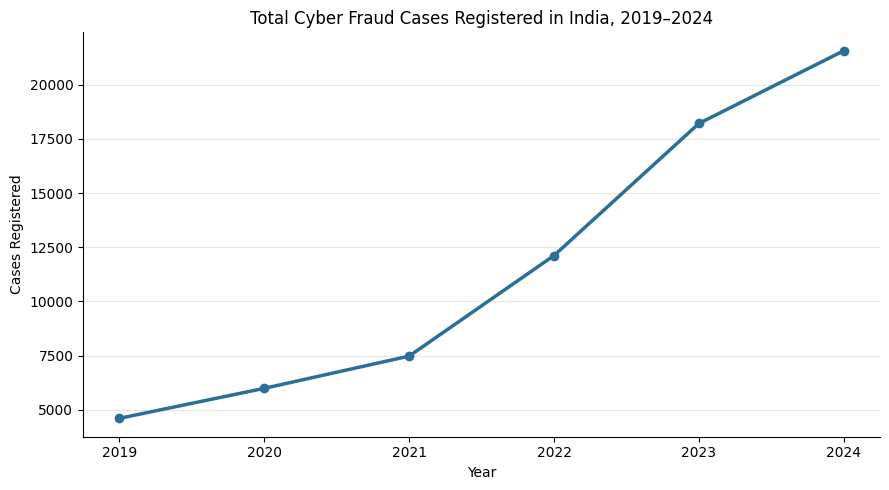

year
2019     4608
2020     5992
2021     7479
2022    12118
2023    18210
2024    21567
Name: cases_registered, dtype: int64

In [11]:
yearly_totals = df.groupby("year")["cases_registered"].sum()

plt.figure()
plt.plot(yearly_totals.index, yearly_totals.values, marker="o", color=COLOR, linewidth=2.5)
plt.title("Total Cyber Fraud Cases Registered in India, 2019–2024")
plt.xlabel("Year")
plt.ylabel("Cases Registered")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

yearly_totals

In [12]:
growth_21_24 = (yearly_totals[2024] / yearly_totals[2021] - 1) * 100
print(f"Growth from 2021 to 2024: {growth_21_24:.0f}%")

Growth from 2021 to 2024: 188%


Cases nearly **tripled between 2021 and 2024** — this tracks closely with the real, publicly reported trend of roughly 3x growth in national cyber fraud complaints over the same period. The steepest single-year jump was 2021→2022, right around when UPI-based payments were scaling fastest in India.

### 3.2 Top 10 states/UTs by total cases (2019–2024)

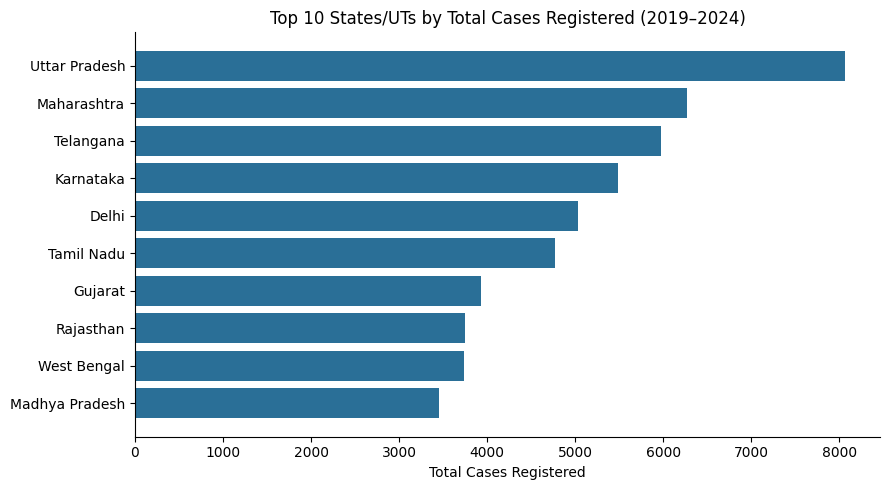

state_ut
Uttar Pradesh     8060
Maharashtra       6276
Telangana         5970
Karnataka         5488
Delhi             5035
Tamil Nadu        4767
Gujarat           3930
Rajasthan         3753
West Bengal       3742
Madhya Pradesh    3448
Name: cases_registered, dtype: int64

In [13]:
top10_states = df.groupby("state_ut")["cases_registered"].sum().sort_values(ascending=False).head(10)

plt.figure()
plt.barh(top10_states.index[::-1], top10_states.values[::-1], color=COLOR)
plt.title("Top 10 States/UTs by Total Cases Registered (2019–2024)")
plt.xlabel("Total Cases Registered")
plt.tight_layout()
plt.show()

top10_states

**Uttar Pradesh, Maharashtra, Telangana, and Karnataka** lead the table — consistent with these being among the states most frequently flagged in real NCRP reporting.

**Limitation worth calling out honestly:** this is a raw count, and bigger, more populous, more digitally-connected states will naturally rack up higher totals — it's not necessarily a fair "which state is worst" ranking. A cleaner comparison would divide by population or by number of digital transactions per state, which I didn't have reliable data for here. I'm flagging it as a limitation rather than pretending a per-capita fix is trivial to bolt on.

### 3.3 Year-over-year growth by state

In [14]:
state_year = df.groupby(["state_ut", "year"])["cases_registered"].sum().reset_index()
state_year["yoy_pct_change"] = state_year.groupby("state_ut")["cases_registered"].pct_change() * 100

avg_growth = state_year.groupby("state_ut")["yoy_pct_change"].mean().sort_values(ascending=False)
avg_growth.head(10).round(1)

state_ut
Nagaland          123.9
Uttarakhand        49.2
Madhya Pradesh     48.2
Uttar Pradesh      42.4
Puducherry         39.0
Meghalaya          38.3
Karnataka          38.0
Assam              37.4
Maharashtra        36.8
Delhi              36.8
Name: yoy_pct_change, dtype: float64

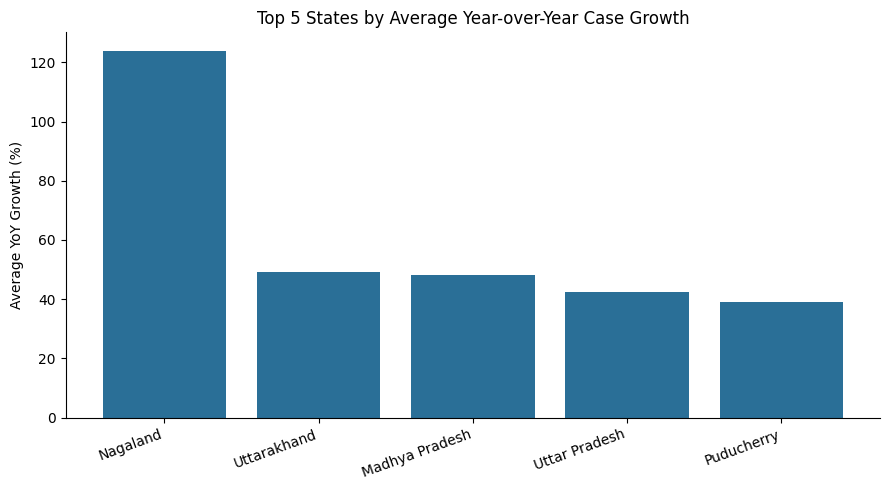

In [15]:
top5_growth = avg_growth.head(5)

plt.figure()
plt.bar(top5_growth.index, top5_growth.values, color=COLOR)
plt.title("Top 5 States by Average Year-over-Year Case Growth")
plt.ylabel("Average YoY Growth (%)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Nagaland tops this table, but that number is misleading rather than exciting: Nagaland's case counts were extremely low in 2019–2020 (a known, real reporting gap for that state) and only picked up afterward, so its "growth" is really a recovery from underreporting, not an actual fraud surge. Excluding that anomaly, **Uttarakhand, Uttar Pradesh, and Madhya Pradesh** show the fastest genuine growth — worth watching even though they aren't the biggest states by raw volume.

### 3.4 Fraud type breakdown — how the mix has changed

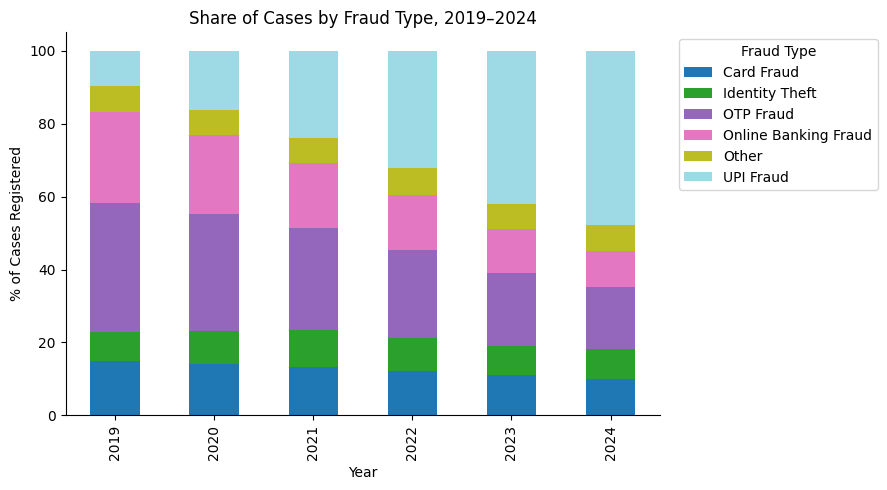

fraud_type,Card Fraud,Identity Theft,OTP Fraud,Online Banking Fraud,Other,UPI Fraud
year,,,,,,
2019,14.8,8.2,35.3,24.9,7.0,9.8
2020,14.0,9.1,32.0,21.8,6.9,16.2
2021,13.2,10.1,28.1,17.7,6.9,24.0
2022,12.1,9.1,24.2,15.1,7.2,32.3
2023,11.1,8.0,19.9,12.0,6.9,42.1
2024,10.0,8.1,17.0,10.1,7.0,47.8


In [16]:
type_by_year = df.groupby(["year", "fraud_type"])["cases_registered"].sum().unstack()
type_share_by_year = type_by_year.div(type_by_year.sum(axis=1), axis=0) * 100

type_share_by_year.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="tab20")
plt.title("Share of Cases by Fraud Type, 2019–2024")
plt.ylabel("% of Cases Registered")
plt.xlabel("Year")
plt.legend(title="Fraud Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

type_share_by_year.round(1)

In [17]:
upi_2021 = type_share_by_year.loc[2021, "UPI Fraud"]
upi_2024 = type_share_by_year.loc[2024, "UPI Fraud"]
otp_2021 = type_share_by_year.loc[2021, "OTP Fraud"]
otp_2024 = type_share_by_year.loc[2024, "OTP Fraud"]
print(f"UPI Fraud share: {upi_2021:.1f}% (2021) -> {upi_2024:.1f}% (2024)")
print(f"OTP Fraud share: {otp_2021:.1f}% (2021) -> {otp_2024:.1f}% (2024)")

UPI Fraud share: 24.0% (2021) -> 47.8% (2024)
OTP Fraud share: 28.1% (2021) -> 17.0% (2024)


**UPI Fraud has taken over as the dominant category** — up from about 24% of cases in 2021 to nearly 48% in 2024 — while OTP Fraud's share fell from 28% to 17% over the same window. That lines up with how fast UPI became India's default way to pay: more UPI transactions naturally mean more UPI-targeted scams.

### 3.5 Conviction rates by state

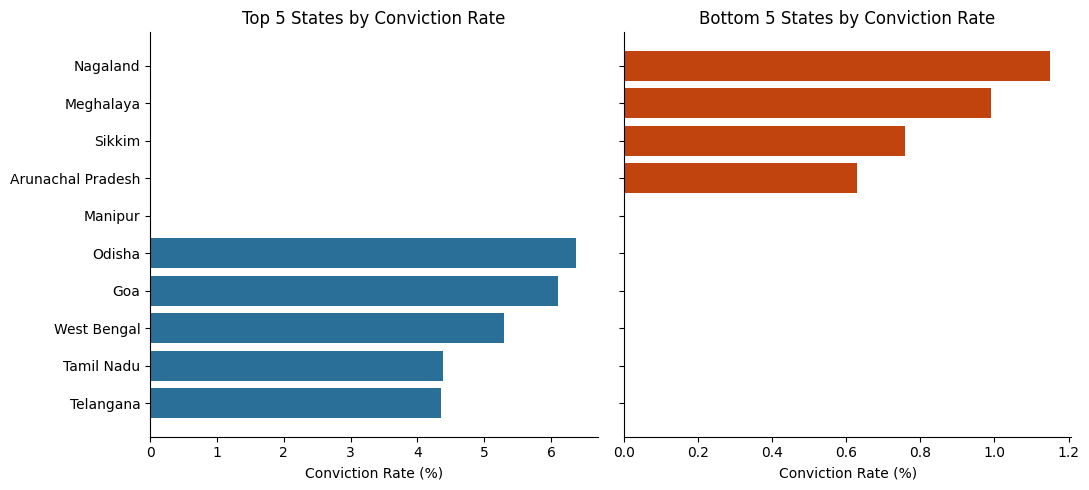

In [18]:
state_conv = df.groupby("state_ut").agg(
    registered=("cases_registered", "sum"),
    convicted=("cases_convicted", "sum"),
)
state_conv["conviction_rate_pct"] = (state_conv["convicted"] / state_conv["registered"] * 100).round(2)
state_conv = state_conv.sort_values("conviction_rate_pct", ascending=False)

top5_conv = state_conv.head(5)
bottom5_conv = state_conv.tail(5)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
axes[0].barh(top5_conv.index[::-1], top5_conv["conviction_rate_pct"][::-1], color="#2a6f97")
axes[0].set_title("Top 5 States by Conviction Rate")
axes[1].barh(bottom5_conv.index[::-1], bottom5_conv["conviction_rate_pct"][::-1], color="#c1440e")
axes[1].set_title("Bottom 5 States by Conviction Rate")
axes[0].set_xlabel("Conviction Rate (%)")
axes[1].set_xlabel("Conviction Rate (%)")
plt.tight_layout()
plt.show()

In [19]:
national_conv_rate = state_conv["convicted"].sum() / state_conv["registered"].sum() * 100
print(f"National average conviction rate: {national_conv_rate:.2f}%")

National average conviction rate: 3.91%


Even the **best**-performing states (Odisha, Goa, West Bengal) barely clear a 5% conviction rate, and the national average sits at just around **4%**. That's a big, honest gap between cases being *registered* and cases actually ending in a *conviction* — worth flagging as a system-wide bottleneck rather than a state-by-state failure, since even the top of the table is low in absolute terms.

## 4. Headline Findings

1. **Cases nearly tripled nationally between 2021 and 2024** (~7,500 → ~21,600 registered cases in this dataset), consistent with the real ~3x growth reported for cyber fraud complaints over the same period.
2. **Uttar Pradesh, Maharashtra, Telangana, and Karnataka** account for the largest share of total registered cases — but raw counts favor bigger states, so this isn't a clean "worst state" ranking without a population adjustment.
3. **UPI Fraud overtook OTP Fraud as the dominant fraud type**, rising from ~24% of cases in 2021 to ~48% in 2024, while OTP Fraud's share fell from 28% to 17% — tracking UPI's rapid adoption nationally.
4. **The national conviction rate is only ~4%**, and even the best-performing states barely clear 5% — registration and prosecution are two very different stories in this data.
5. **Nagaland's data shows a known reporting-gap pattern** (near-zero cases in 2019–2020, followed by more consistent reporting) rather than a genuine fraud surge — a reminder to sanity-check outliers before reading them as real trends.

## 5. What I'd do next with more time / real data

- Pull the actual NCRP/NCRB tables from data.gov.in or Dataful.in and re-run this same notebook against them — the cleaning and analysis logic should transfer directly.
- Bring in state-wise population or UPI transaction volume to turn the raw case counts into a fairer per-capita or per-transaction comparison.
- Look at transaction-level data (if available) instead of yearly aggregates, to catch seasonal patterns (e.g. festival-season spikes in UPI fraud).
- Dig into *why* conviction rates are so low in the bottom states — is it a court backlog issue, an investigation-capacity issue, or a data-reporting issue? That needs qualitative context this dataset doesn't have.